In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

from preprocessing import enhance_contrast, gamma_correction, edge_detection, image_negative

In [2]:
dataset_path = "C:/Users/dell/Downloads/fake_image_detection/dataset"

In [3]:
import random
random.seed(42)
data = []
labels = []

categories = ["Real", "Fake"]

limit = 2000

for category in categories:
    path = os.path.join(dataset_path, category)
    label = 0 if category == "Real" else 1
    
    all_images = os.listdir(path)

    selected_images = random.sample(all_images, min(limit, len(all_images)))
    
    for img_name in selected_images:
        img_path = os.path.join(path, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image = enhance_contrast(image)
        image = gamma_correction(image)

        image = cv2.resize(image, (128,128))

        data.append(image)
        labels.append(label)

data = np.array(data) / 255.0
labels = np.array(labels)

print("Total images loaded:", len(data))

Total images loaded: 4000


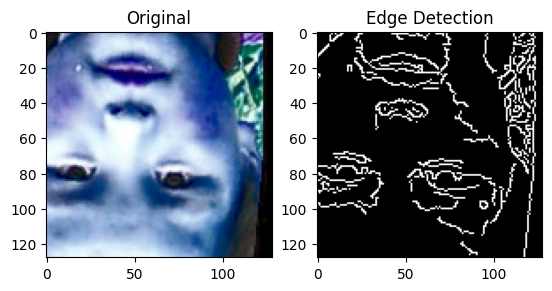

In [4]:
sample = data[0]

edges = edge_detection((sample * 255).astype(np.uint8))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")

plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

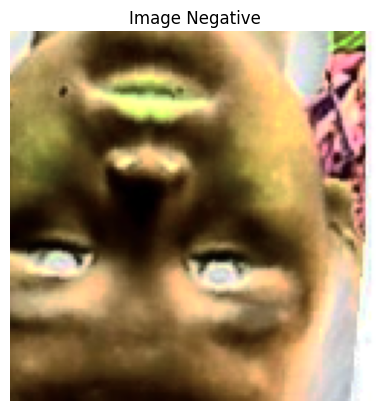

In [5]:
negative = image_negative((sample * 255).astype(np.uint8))

plt.imshow(negative)
plt.title("Image Negative")
plt.axis("off")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [7]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - accuracy: 0.5322 - loss: 0.7144 - val_accuracy: 0.6325 - val_loss: 0.6592
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - accuracy: 0.6237 - loss: 0.6533 - val_accuracy: 0.6425 - val_loss: 0.6405
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step - accuracy: 0.6756 - loss: 0.5980 - val_accuracy: 0.6500 - val_loss: 0.6341
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.7212 - loss: 0.5418 - val_accuracy: 0.6475 - val_loss: 0.6603
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.7669 - loss: 0.4778 - val_accuracy: 0.6787 - val_loss: 0.6044


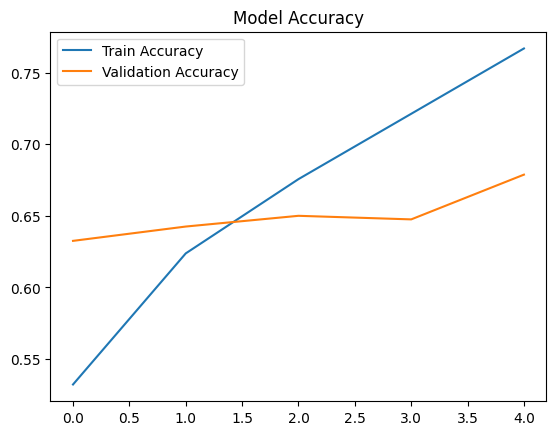

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [11]:
model.save("model/deepfake_model.h5")

In [12]:
accuracy = model.evaluate(X_test, y_test)[1]

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6787 - loss: 0.6044


In [13]:
accuracy

0.6787499785423279